In [21]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option(
    "display.max_colwidth", 12,
    "display.max_rows", 20,
    "display.max_columns", 50,
    "display.precision", 4
)
plt.style.use('../utils/MyStyle.txt')
cm = 1/2.54
palette = ["#3F3517",  '#CE2E31', '#C96F6B', '#CCA464', '#F8D768', '#F0DCD4']

### 3 Steps, 1 Supervisor
Try to do the absa using a single prompt

In [2]:
import pandas as pd
import dspy
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from concurrent.futures import ThreadPoolExecutor, as_completed

from tqdm.auto import tqdm
tqdm.pandas()

import sys
sys.path.append("../utils")

# import graph_1
from graph_2_contex_v3 import *
from graph_2_graph_v3 import *

In [3]:
graph = StateGraph(ABSAState)

graph.add_node("agent_initiation", node_initiation)
graph.add_node("ATE", node_ate)
graph.add_node("OTE", node_ote)
graph.add_node("ALSC", node_alsc)
graph.add_node("Supervision", node_supervision)

graph.add_edge("agent_initiation", "ATE")
graph.add_edge("ATE", "OTE")

graph.add_conditional_edges(
    "OTE",    # Source node
    should_do_alsc, # Action
    {
        "ATE": "ATE",
        "ALSC": "ALSC"        
    })

graph.add_conditional_edges(
    "ALSC",    # Source node
    should_do_supervision, # Action
    {
        "OTE": "OTE",
        "Supervision": "Supervision", 
    })

graph.add_conditional_edges(
    "Supervision",    # Source node
    should_finish_absa, # Action
    {
        "ATE": "ATE",
        "OTE": "OTE", 
        "ALSC": "ALSC",   
        "END": END        
    })


graph.set_entry_point("agent_initiation")

app = graph.compile(checkpointer=MemorySaver())

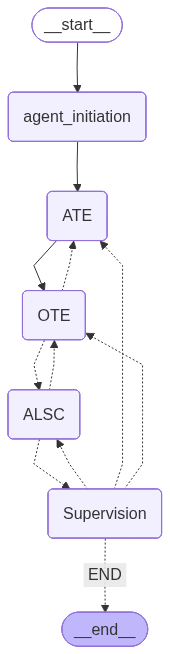

In [4]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [5]:
# app.get_graph().print_ascii()

In [6]:
def run_absa_for_review(review_text: str, review_id: int, place_name: str):
    """Run your ABSA LangGraph pipeline on a single review."""
    try:
        # Create the initial state dynamically for each review
        state = ABSAState(
            place_name = place_name,
            review = review_text,
            review_id = review_id,

            aspects = [],
            aspects_decision = "",
            aspects_rationale = "",
            aspects_counter = 0,

            opinions = [],
            opinions_decision = "",
            opinions_rationale = "",
            opinions_counter = 0,

            sentiments = [],
            sentiments_decision = "",
            sentiments_rationale = "",
            sentiments_counter = 0,
        )

        # Run the graph
        result = app.invoke(state, {"recursion_limit": 100, "thread_id":review_id})

        # Extract only the relevant outputs
        return {
            "aspects": result.get("aspects", []),
            "aspects_counter": result.get("aspects_counter", 0),
            "opinions": result.get("opinions", []),
            "opinions_counter": result.get("opinions_counter", 0),
            "sentiments": result.get("sentiments", []),
            "sentiments_counter": result.get("sentiments_counter", 0),
            "supervision_counter": result.get("supervision_counter", 0),
        }

    except Exception as e:
        print(f"Error for review: {review_text[:25]}... -> {e}")
        return {
            "aspects": [],
            "aspects_counter": 0,
            "opinions": [],
            "opinions_counter": 0,
            "sentiments": [],
            "sentiments_counter": 0,
            "supervision_counter": 0,
        }

def run_absa_row(row):
    return row["ind"], run_absa_for_review(row["text"], int(row["ind"]), row["place_name"])

In [7]:
df2 = pd.read_excel('../data/1000_annotated_sample_final.xlsx')
df2 = df2.drop(columns=(['Unnamed: 0', 'flag']))
df2['ind'] = df2.index.astype(int)
df2.shape

(1000, 33)

In [8]:
# import pprint
# review_id = 67
# print('place_name:', df2.loc[review_id, 'place_name'])
# print(20 * '*')
# print('Review: ')
# pprint.pp(df2.loc[review_id, 'text'])

In [9]:
import pprint

review_id = 62

res2 = run_absa_for_review(review_text=df2.loc[review_id, 'text'], 
                            review_id=int(df2.loc[review_id, 'ind']), 
                            place_name=df2.loc[review_id, 'place_name'])

print('place_name:', df2.loc[review_id, 'place_name'])
print(20 * '*')
print('Review: ')
pprint.pp(df2.loc[review_id, 'text'])
print(20 * '*')
print('ABSA_manual: ')
pprint.pp(json.loads(df2.loc[review_id, 'ABSA_manual']))
print(20 * '*')
print('result: ')
pprint.pp(res2)

place_name: Mates Gym - Best 24hrs Weight Loss Gym | Creche | Cheap Gym Membership | Zumba & Bhangra Classes
********************
Review: 
('Always plays Bollywood music.  Not enough classes, Zumba is the only decent '
 'class!!  The place has gone downward since it opened tbh.  It pretty much '
 'caters and focuses on a certain group.')
********************
ABSA_manual: 
{'overall_sentiment': 'negative',
 'aspects': [{'aspect': 'music',
              'category': 'Ambience',
              'sentiment': 'negative',
              'evidence_span': 'Bollywood music'},
             {'aspect': 'classes',
              'category': 'Facilities',
              'sentiment': 'negative',
              'evidence_span': 'Not enough classes'},
             {'aspect': 'Zumba',
              'category': 'Facilities',
              'sentiment': 'positive',
              'evidence_span': 'only decent class'},
             {'aspect': 'quality',
              'category': 'General',
              'sentiment'

In [10]:
results = {}

with ThreadPoolExecutor(max_workers=10) as executor:
    futures = {
        executor.submit(run_absa_row, row): idx
        for idx, row in df2.iterrows()
    }

    for future in tqdm(as_completed(futures), total=len(futures), desc="Running ABSA in parallel"):
        ind, res = future.result()
        results[ind] = res

df2["absa_results"] = df2["ind"].map(results)
df2["sentiments"] = df2["absa_results"].apply(lambda x: x["sentiments"])

Running ABSA in parallel:   0%|          | 0/1000 [00:00<?, ?it/s]

Error for review: Decided to come here inst... -> Recursion limit of 100 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/GRAPH_RECURSION_LIMIT
Error for review: After reading glowing rev... -> Recursion limit of 100 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/GRAPH_RECURSION_LIMIT
Error for review: Really nice weekend - gre... -> Recursion limit of 100 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/GRAPH_RECURSION_LIMIT
Error for review: Been going periodically f... -> Recursion limit of 100 reached without hitting a stop condition. You can i

In [11]:
# df2["absa_results"] = df2.progress_apply(func= lambda row: run_absa_for_review(review_text=row["text"], review_id=row["ind"]),
#                                         axis=1)

# df2["sentiments"] = df2["absa_results"].apply(lambda x: x["sentiments"])

In [13]:
df2.to_excel('1000_annotated_sample_final_graph_2_v3.xlsx')

# Validation results

In [2]:
import spacy
import numpy as np
import pandas as pd
import seaborn as sns
import json
import ast
import re

In [3]:
df = pd.read_excel("../data/1000_annotated_sample_final.xlsx")

df1 = pd.read_excel("../results/1000_annotated_sample_final_graph_1_v2.xlsx")
df2 = pd.read_excel("../results/1000_annotated_sample_final_graph_2_v2.xlsx")
df3 = pd.read_excel("../results/1000_annotated_sample_final_graph_3_v2.xlsx")


df1 = df1.add_suffix('_graph_1')
df2 = df2.add_suffix('_graph_2')
df3 = df3.add_suffix('_graph_3')

merged_df = pd.concat([df1, df2, df3], axis=1)

merged_df = df.merge(merged_df, 
                        left_on=['place_id', 'author'],
                        right_on=['place_id_graph_1', 'author_graph_1'],
                        how='inner')

df4 = pd.read_excel("../results/1000_annotated_sample_final_graph_2_v3.xlsx")
df4 = df4.add_suffix('_graph_4')

merged_df = merged_df.merge(df4, 
                            left_on=['place_id', 'author'],
                            right_on=['place_id_graph_4', 'author_graph_4'],
                            how='inner')
merged_df.head(2)

,Unnamed: 0,place_id,author,join_col,rating,date,text,place_name,index,date_parsed,ABSA_manual,atepc_json,flag,len_manual,len_atepc,len_g1,len_g2,len_g3,len_g4,diff_g1,diff_g2,diff_g3,diff_g4,xgn,Unnamed: 24,...,Unnamed: 0_graph_3,place_id_graph_3,author_graph_3,rating_graph_3,date_graph_3,text_graph_3,place_name_graph_3,index_graph_3,date_parsed_graph_3,ABSA_manual_graph_3,atepc_json_graph_3,absa_results_graph_3,sentiments_graph_3,Unnamed: 0_graph_4,place_id_graph_4,author_graph_4,rating_graph_4,date_graph_4,text_graph_4,place_name_graph_4,index_graph_4,date_parsed_graph_4,ABSA_manual_graph_4,absa_results_graph_4,sentiments_graph_4
0,255,ChIJ3SGS...,Chloe Ra...,ChIJ3SGS...,1,a year ago,Waste of...,IceBar S...,15776,2024-10-10,"{""overal...",{'senten...,1.0,7,2,8,7,6,8,-1,0,1,-1,[{'aspec...,43.0,...,752,ChIJ3SGS...,Chloe Ra...,1,a year ago,Waste of...,IceBar S...,15776,2024-10-10,"{""overal...",{'senten...,{'absa_f...,[{'aspec...,996,ChIJ3SGS...,Chloe Ra...,1,a year ago,Waste of...,IceBar S...,15776,2024-10-10,"{""overal...",{'aspect...,[{'aspec...
1,1480,ChIJoWNw...,Colin wick,ChIJoWNw...,4,a year ago,Great sp...,The West...,434,2024-10-10,"{""overal...",{'senten...,NaN,5,5,9,9,5,7,-4,-4,0,-2,[{'aspec...,43.0,...,980,ChIJoWNw...,Colin wick,4,a year ago,Great sp...,The West...,434,2024-10-10,"{""overal...",{'senten...,{'absa_f...,[{'aspec...,995,ChIJoWNw...,Colin wick,4,a year ago,Great sp...,The West...,434,2024-10-10,"{""overal...",{'aspect...,[{'aspec...


In [4]:
import ast

def dedup_aspects(lst):
    seen = set()
    result = []
    for item in lst:
        key = (item['aspect'], item['sentiment'])
        if key not in seen:
            seen.add(key)
            result.append(item)
    return result

# merged_df['ABSA_manual'] = merged_df['ABSA_manual'].apply(dedup_aspects)
merged_df['sentiments_graph_1'] = merged_df['sentiments_graph_1'].apply(ast.literal_eval)
merged_df['sentiments_graph_2'] = merged_df['sentiments_graph_2'].apply(ast.literal_eval)
merged_df['sentiments_graph_3'] = merged_df['sentiments_graph_3'].apply(ast.literal_eval)
merged_df['sentiments_graph_4'] = merged_df['sentiments_graph_4'].apply(ast.literal_eval)

merged_df['sentiments_graph_1'] = merged_df['sentiments_graph_1'].apply(dedup_aspects)
merged_df['sentiments_graph_2'] = merged_df['sentiments_graph_2'].apply(dedup_aspects)
merged_df['sentiments_graph_3'] = merged_df['sentiments_graph_3'].apply(dedup_aspects)
merged_df['sentiments_graph_4'] = merged_df['sentiments_graph_4'].apply(dedup_aspects)

In [ ]:
from openai import OpenAI

GPT_API_KEY = ''
client = OpenAI(api_key = GPT_API_KEY)

def get_embedding(text, model="text-embedding-3-large"):
    text = text.replace("\n", " ")
    return client.embeddings.create(input = [text], model=model).data[0].embedding

In [6]:
nlp = spacy.load('en_core_web_lg')

def cosine_similarity(word_a: str, word_b: str) -> float:
    vector_a = nlp(word_a).vector
    vector_b = nlp(word_b).vector
    # vector_a = get_embedding(word_a)
    # vector_b = get_embedding(word_b)
    dot_product = np.dot(vector_a, vector_b)
    magnitude_a = np.linalg.norm(vector_a)
    magnitude_b = np.linalg.norm(vector_b)
    return dot_product / (magnitude_a * magnitude_b)

def parse_col1(x):
    if not isinstance(x, str):
        return []
    try:
        return json.loads(x).get("aspects", [])
    except Exception:
        return []

def parse_col2(x):
    if not x:
        return []
    try:
        return ast.literal_eval(x)
    except Exception:
        return x 

def normalize(a):
    return a.lower().strip()

def compare_aspects(aspects1, aspects2):
    matches = 0
    l = []
    try:
        for a1 in aspects1:
            asp1 = normalize(a1.get("aspect", ""))
            sent1 = normalize(a1.get("sentiment", ""))

            for a2 in aspects2:
                asp2 = normalize(a2.get("aspect", ""))
                sent2 = normalize(a2.get("sentiment", ""))
                
                if cosine_similarity(asp1, asp2) >= 0.55 and (asp2 not in l): 
                    if sent1 == sent2:
                        matches += 1
                        break
    except Exception:
        return None
    return matches


def node_nlp_extract_pairs(nlp_text: str) -> str:
    """Extract aspects & sentiments from the NLP-annotated fields."""
    raw = nlp_text
    if not raw:
        aspects = []
        sentiments = []

    try:
        parsed = ast.literal_eval(raw)
    except Exception as e:
        aspects = []
        sentiments = []

    aspects = [str(a).strip() for a in parsed.get("aspect", []) or []]
    labels  = [str(s).strip().lower() for s in parsed.get("sentiment", []) or []]

    allowed = {"positive", "negative", "neutral"}
    items = []
    for a, lab in zip(aspects, labels):
        lab = lab if lab in allowed else "neutral"
        items.append({"aspect": a, "opinion": "", "sentiment": lab})
  
    return items

In [7]:
# cosine_similarity("access", 'accessibility')

In [8]:
# merged_df.columns

In [ ]:
merged_df["aspects_manual"] = merged_df["ABSA_manual"].apply(parse_col1)
merged_df["atepc_json"] = merged_df["atepc_json_graph_1"].apply(node_nlp_extract_pairs)
merged_df["aspects_graph_1"] = merged_df["sentiments_graph_1"].apply(parse_col2)
merged_df["aspects_graph_2"] = merged_df["sentiments_graph_2"].apply(parse_col2)
merged_df["aspects_graph_3"] = merged_df["sentiments_graph_3"].apply(parse_col2)
merged_df["aspects_graph_4"] = merged_df["sentiments_graph_4"].apply(parse_col2)

In [62]:
# merged_df.loc[0, "text_graph_2"]

In [63]:
# merged_df.loc[0, "aspects_manual"]

In [64]:
# merged_df.apply(lambda row: compare_aspects(row["aspects_manual"], row["aspects_graph_1"]), axis=1).sum()

In [65]:
# merged_df.apply(lambda row: compare_aspects(row["aspects_manual"], row["aspects_graph_2"]), axis=1).sum()

In [66]:
# merged_df.apply(lambda row: compare_aspects(row["aspects_manual"], row["aspects_graph_4"]), axis=1).sum()

In [67]:
# absa_cols = [
#     "aspects_manual",
#     "atepc_json",
#     "aspects_graph_1",
#     "aspects_graph_2",
#     "aspects_graph_3",
#     "aspects_graph_4",
# ]

# n = len(absa_cols)

# # Extract columns as NumPy arrays (object dtype is fine)
# col_data = [merged_df[col].to_numpy() for col in absa_cols]

# match_matrix = np.zeros((n, n), dtype=int)

# for i in range(n):
#     for j in range(i, n):  # only compute upper triangle
#         # compare_aspects should return an int (0 or 1 usually)
#         s = 0
#         a_i = col_data[i]
#         a_j = col_data[j]
#         for x, y in zip(a_i, a_j):
#             s += compare_aspects(x, y)
#         match_matrix[i, j] = s
#         match_matrix[j, i] = s   # fill symmetric element

# # Percent matrix using broadcasting, no Python loops
# diag = match_matrix.diagonal().astype(float)
# percent_matrix = np.zeros_like(match_matrix, dtype=float)

# # avoid division by zero if any diagonal is zero
# nonzero = diag != 0
# percent_matrix[nonzero, :] = match_matrix[nonzero, :] / diag[nonzero, None] * 100


In [10]:
absa_cols = [
    "aspects_manual",
    # "atepc_json",
    "aspects_graph_1",
    "aspects_graph_2",
    "aspects_graph_3",
    "aspects_graph_4",
]

n = len(absa_cols)
match_matrix = np.zeros((n, n), dtype=int)

for i in range(n):
    for j in range(i, n):
        # j = 0
        # if i <= j: 
            print(i, ', ', j)
            match_matrix[i, j] = merged_df.apply(
                                                lambda row: compare_aspects(row[absa_cols[i]], row[absa_cols[j]]),
                                                axis=1
                                        ).sum()
            match_matrix[j, i] = match_matrix[i, j]

percent_matrix = np.zeros(match_matrix.shape)
for i in range(n):
    total= match_matrix[i, i]
    for j in range(n):
        percent_matrix[i, j] = (match_matrix[i, j] / total) * 100 

0 ,  0


C:\Users\asus\AppData\Local\Temp\ipykernel_12076\3696901253.py:11: RuntimeWarning: invalid value encountered in scalar divide
  return dot_product / (magnitude_a * magnitude_b)


0 ,  1
0 ,  2
0 ,  3
0 ,  4
1 ,  1
1 ,  2
1 ,  3
1 ,  4
2 ,  2
2 ,  3
2 ,  4
3 ,  3
3 ,  4
4 ,  4


In [11]:
# # mask = np.triu(np.ones_like(match_matrix, dtype=bool))


# plt.figure(figsize=(8, 6))
# sns.heatmap(
#     match_matrix,
#     annot=True,
#     fmt='.1f',        
#     cmap='Blues',
#     # mask=~mask,        
#     xticklabels=absa_cols,
#     yticklabels=absa_cols,
#     square=True,       
#     linewidths=0.5,
#     cbar_kws={"label": "Match Percentage (%)"}
# )

# plt.title("Pairwise ABSA Matches (Bottom Half Only)")
# plt.tight_layout()
# plt.show()

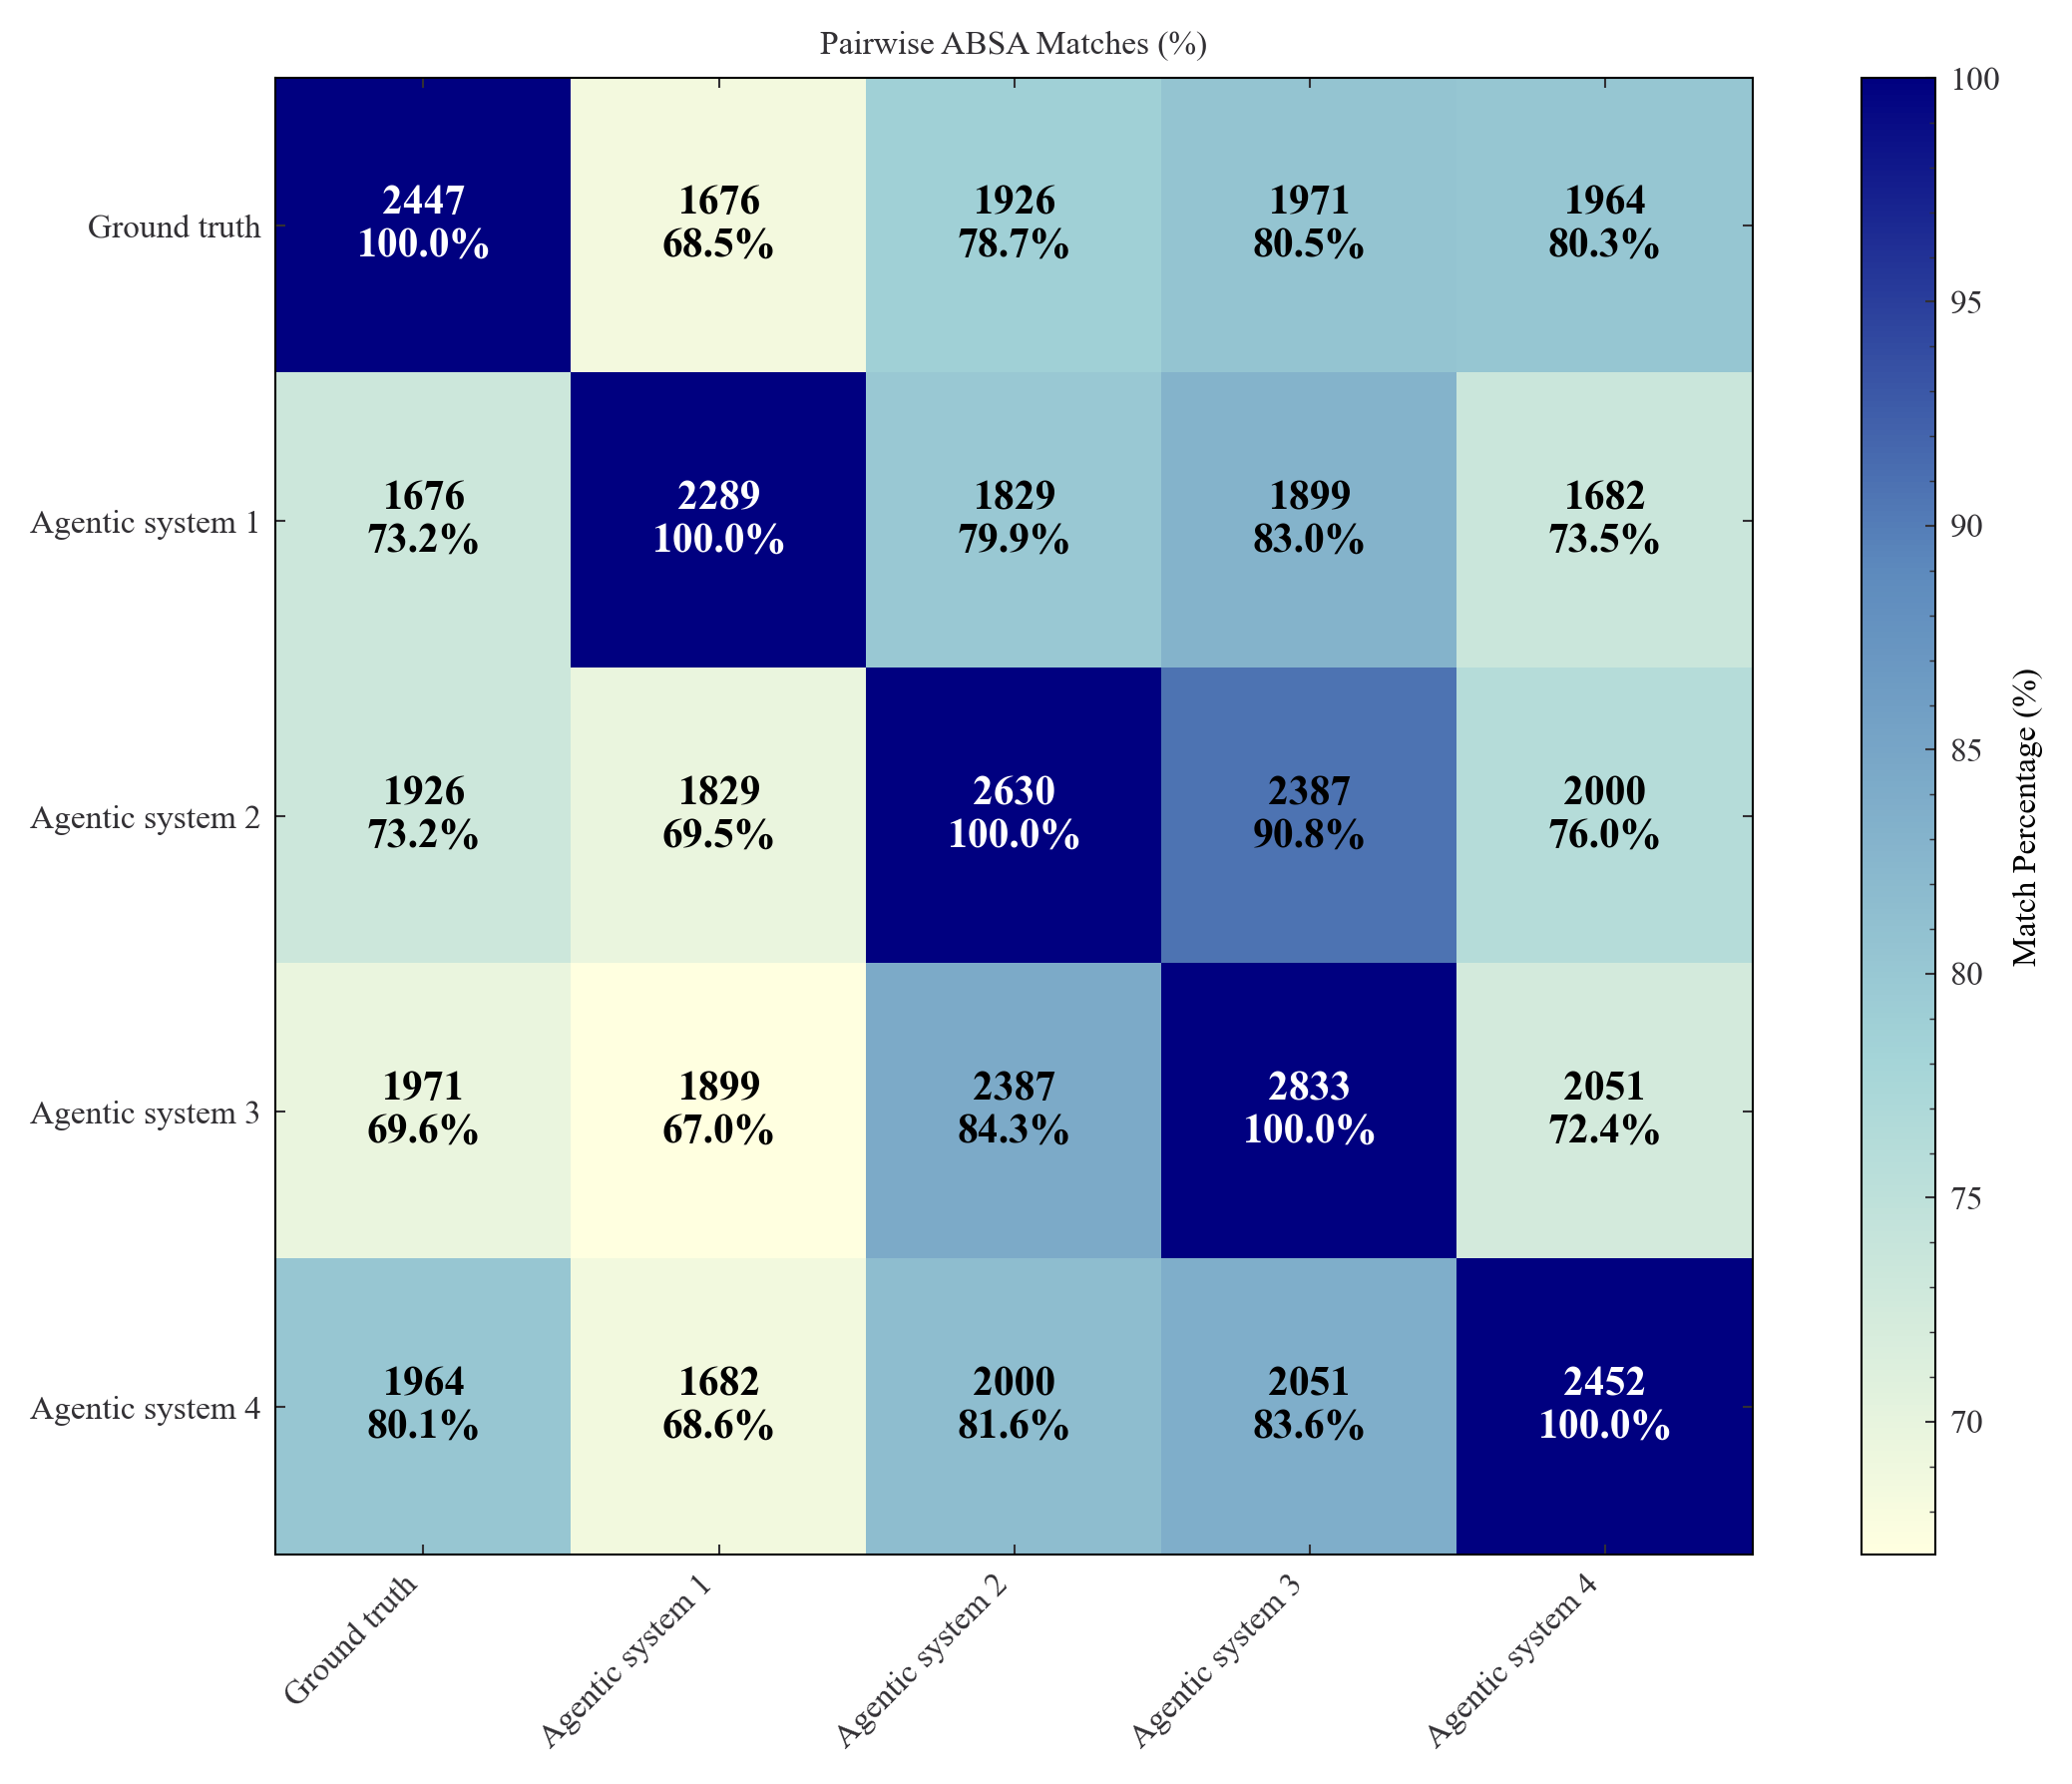

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import colorsys


# new_order = [
#     "aspects_manual",
#     "aspects_graph_3",
#     "aspects_graph_2",
#     "aspects_graph_1",
#     "aspects_graph_4",
# ]

# idx = [absa_cols.index(c) for c in new_order]

# match_matrix = match_matrix[np.ix_(idx, idx)]
# percent_matrix = percent_matrix[np.ix_(idx, idx)]
# absa_cols = [absa_cols[i] for i in idx]
# n = len(absa_cols)

# # ---- 2) rename columns ----
# rename_map = {
#     "aspects_manual":  "Ground truth",
#     "aspects_graph_3": "Agentic system 1",
#     "aspects_graph_2": "Agentic system 2",
#     "aspects_graph_1": "Agentic system 3",
#     "aspects_graph_4": "Agentic system 4",
# }
# absa_cols = [rename_map[c] for c in absa_cols]

# ---- 3) build colormap from your palette (sorted by lightness) ----
def hex_to_rgb01(hex_color: str):
    hex_color = hex_color.lstrip("#")
    return tuple(int(hex_color[i:i+2], 16) / 255 for i in (0, 2, 4))

palette_sorted = sorted(
    palette,
    key=lambda c: colorsys.rgb_to_hls(*hex_to_rgb01(c))[1],
    reverse=True
)

cmap = LinearSegmentedColormap.from_list("my_cmap", palette_sorted, N=256)

# ---- 4) plot ----
plt.figure(figsize=(8, 6))
plt.imshow(percent_matrix, cmap=cmap, interpolation="nearest")
plt.colorbar(label="Match Percentage (%)")

for i in range(n):
    for j in range(n):
        # switch text color based on background intensity
        color = "white" if percent_matrix[i, j] > 91 else "black"
        plt.text(
            j, i,
            f"{match_matrix[i, j]}\n{percent_matrix[i, j]:.1f}%",
            ha="center", va="center",
            color=color, fontsize=10, fontweight="bold"
        )

plt.xticks(range(n), absa_cols, rotation=45, ha="right")
plt.yticks(range(n), absa_cols)
plt.title("Pairwise ABSA Matches (%)")
plt.tight_layout()
ax = plt.gca()
ax.minorticks_off()
plt.show()


In [40]:
import numpy as np
import pandas as pd

# Assumes you already reordered/renamed and match_matrix is in this order:
# ["Ground truth", "Agentic system 1", "Agentic system 2", "Agentic system 3", "Agentic system 4"]
# and match_matrix[i, i] is the total aspects extracted by system i
# and match_matrix[0, j] is the overlap (TP) between ground truth and system j

gt_idx = 0
systems = absa_cols  # renamed labels

gt_total = match_matrix[gt_idx, gt_idx]

rows = []
for j, name in enumerate(systems):
    if j == gt_idx:
        rows.append({
            "System": name,
            "TP": np.nan, "FP": np.nan, "FN": np.nan,
            "Precision": np.nan, "Recall": np.nan, "F1": np.nan
        })
        continue

    tp = match_matrix[gt_idx, j]
    pred_total = match_matrix[j, j]

    fp = pred_total - tp
    fn = gt_total - tp

    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall    = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    f1        = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else np.nan

    rows.append({
        "System": name,
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn),
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

f1_table = pd.DataFrame(rows)

# pretty formatting
f1_table["Precision"] = f1_table["Precision"].map(lambda x: np.nan if pd.isna(x) else round(x, 3))
f1_table["Recall"]    = f1_table["Recall"].map(lambda x: np.nan if pd.isna(x) else round(x, 3))
f1_table["F1"]        = f1_table["F1"].map(lambda x: np.nan if pd.isna(x) else round(x, 3))

f1_table


,System,TP,FP,FN,Precision,Recall,F1
0,Ground t...,NaN,NaN,NaN,NaN,NaN,NaN
1,Agentic ...,1676.0,613.0,771.0,0.732,0.685,0.708
2,Agentic ...,1926.0,704.0,521.0,0.732,0.787,0.759
3,Agentic ...,1971.0,862.0,476.0,0.696,0.805,0.747
4,Agentic ...,1964.0,488.0,483.0,0.801,0.803,0.802


In [41]:
import pandas as pd
from collections import defaultdict
from math import isnan

In [42]:
def norm(s: str) -> str:
    return str(s).strip().lower()

def cosine_similarity(word_a: str, word_b: str) -> float:
    vector_a = nlp(word_a).vector
    vector_b = nlp(word_b).vector
    dot_product = np.dot(vector_a, vector_b)
    magnitude_a = np.linalg.norm(vector_a)
    magnitude_b = np.linalg.norm(vector_b)
    if magnitude_a == 0 or magnitude_b == 0:
        return 0.0
    return dot_product / (magnitude_a * magnitude_b)


aspect_tp = 0
aspect_fp = 0
aspect_fn = 0

y_true = []  
y_pred = []

SIM_THRESHOLD = 0.7

def find_best_match(gold_aspect, pred_aspects):
    max_sim = -1
    best_match = None
    for pred in pred_aspects:
        sim = cosine_similarity(gold_aspect, pred)
        if sim > max_sim:
            max_sim = sim
            best_match = pred
    return best_match, max_sim

In [43]:
for _, row in merged_df.iterrows():
    gold_list = row["aspects_manual"] or []
    pred_list = row["aspects_graph_4"] or []

    gold_dict = {str(d.get("aspect","")).lower(): str(d.get("sentiment","")).lower()
                 for d in gold_list}
    
    pred_dict = {str(d.get("aspect","")).lower(): str(d.get("sentiment","")).lower()
                 for d in pred_list}

    gold_aspects = set(gold_dict.keys())
    pred_aspects = set(pred_dict.keys())
    
    used_pred = set()
    tp_aspects = set()
    fp_aspects = set()
    fn_aspects = set()

    # Attempt fuzzy matching (gold -> best pred)
    for gold_a in gold_aspects:
        best_pred, sim = find_best_match(gold_a, pred_aspects - used_pred)
        if best_pred is not None and sim >= SIM_THRESHOLD:
            tp_aspects.add((gold_a, best_pred))
            used_pred.add(best_pred)
        else:
            fn_aspects.add(gold_a)

    # Remaining predictions are FPs
    for pred_a in pred_aspects:
        if pred_a not in used_pred:
            fp_aspects.add(pred_a)

    aspect_tp += len(tp_aspects)
    aspect_fp += len(fp_aspects)
    aspect_fn += len(fn_aspects)

    # Sentiment evaluation on matched items
    for gold_a, matched_pred_a in tp_aspects:
        y_true.append(gold_dict[gold_a])
        y_pred.append(pred_dict[matched_pred_a])

In [44]:
precision_aspect = aspect_tp / (aspect_tp + aspect_fp) if (aspect_tp + aspect_fp) > 0 else 0.0
recall_aspect = aspect_tp / (aspect_tp + aspect_fn) if (aspect_tp + aspect_fn) > 0 else 0.0
f1_aspect = (
    2 * precision_aspect * recall_aspect / (precision_aspect + recall_aspect)
    if (precision_aspect + recall_aspect) > 0
    else 0.0
)

print("Aspect extraction using cosine similarity")
print(f"TP: {aspect_tp}  FP: {aspect_fp}  FN: {aspect_fn}")
print(f"Precision: {precision_aspect:.3f}")
print(f"Recall:    {recall_aspect:.3f}")
print(f"F1:        {f1_aspect:.3f}")

Aspect extraction using cosine similarity
TP: 1943  FP: 511  FN: 504
Precision: 0.792
Recall:    0.794
F1:        0.793


In [45]:
labels = ["positive", "negative", "neutral"]
cm = pd.crosstab(
    pd.Categorical(y_true, categories=labels),
    pd.Categorical(y_pred, categories=labels),
    rownames=["gold"],
    colnames=["pred"],
    dropna=False
)

print("\nSentiment confusion matrix (gold rows, pred columns)")
print(cm)


Sentiment confusion matrix (gold rows, pred columns)
pred      positive  negative  neutral
gold                                 
NaN              1         0        0
positive      1020        12       25
negative         7       784       19
neutral         10        12       53


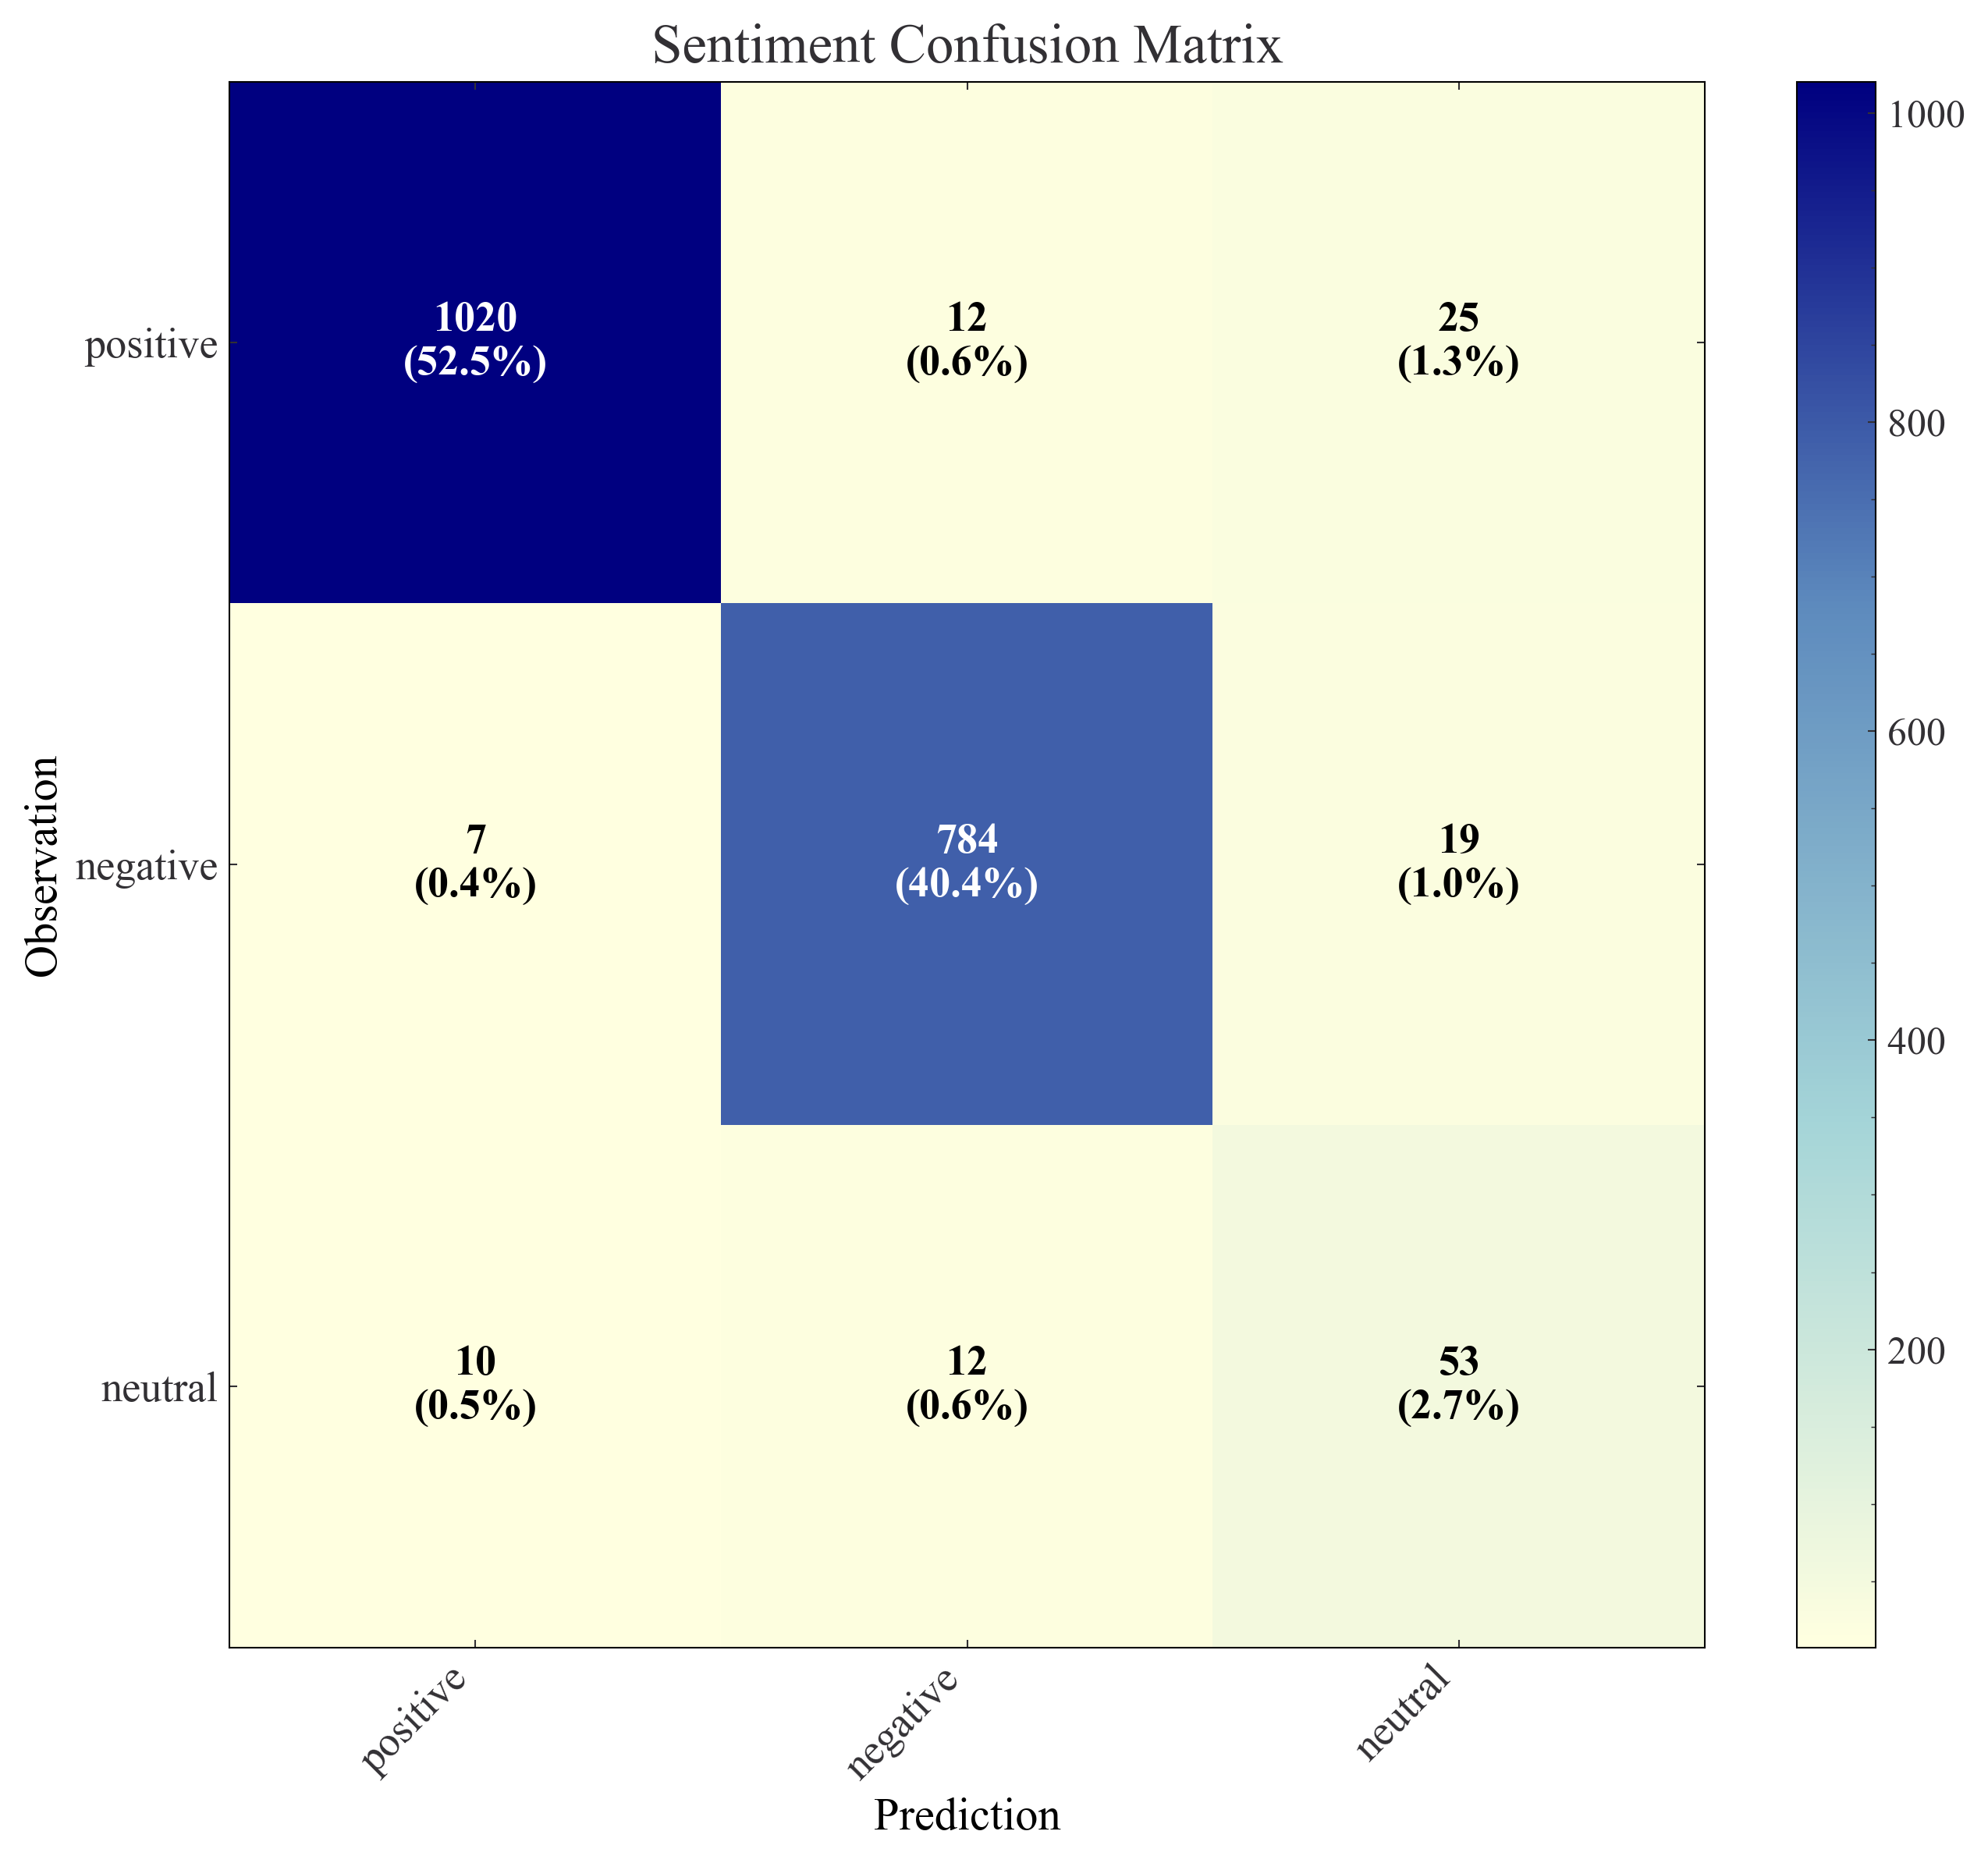

In [47]:
fig, ax = plt.subplots(figsize=(9,8))

# Draw heatmap
if np.nan in cm.index:
    cm = cm.drop(np.nan, axis=0)
cm_values = cm.values
im = ax.imshow(cm_values, aspect="auto", cmap=cmap, interpolation="nearest")

# Set tick labels
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, fontsize=13)
ax.set_yticklabels(labels, fontsize=13)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Calculate total percentages
total = cm_values.sum()
percent_matrix = (cm_values / total) * 100 if total > 0 else np.zeros_like(cm_values, dtype=float)

# Annotate each cell
max_val = cm_values.max()
for i in range(len(labels)):
    for j in range(len(labels)):
        count = cm_values[i, j]
        pct = percent_matrix[i, j]
        color = "black" if count < max_val * 0.5 else "white"
        text = f"{count}\n({pct:.1f}%)"
        ax.text(j, i, text, ha="center", va="center", fontsize=13, color=color, fontweight="bold")

# Axis titles
ax.set_xlabel("Prediction", fontsize=14)
ax.set_ylabel("Observation", fontsize=14)
ax.set_title("Sentiment Confusion Matrix", fontsize=17)

# Colorbar
cbar = plt.colorbar(im)
cbar.ax.tick_params(labelsize=12)
ax = plt.gca()
ax.minorticks_off()
plt.tight_layout()
plt.show()

# Categories

In [29]:
df4.head()

,Unnamed: 0_graph_4,place_id_graph_4,author_graph_4,rating_graph_4,date_graph_4,text_graph_4,place_name_graph_4,index_graph_4,date_parsed_graph_4,ABSA_manual_graph_4,absa_results_graph_4,sentiments_graph_4
0,0,ChIJLyN5...,BREEZY,1,Edited 2...,Disgusti...,Australi...,40939,2023-10-11,"{""overal...",{'aspect...,[{'aspec...
1,1,ChIJxf_c...,Nick Qi,4,a year ago,At the h...,Memorial...,344,2024-10-10,"{""overal...",{'aspect...,[{'aspec...
2,2,ChIJ9_jM...,Eliza Ng...,4,4 years ago,Good spo...,Maits Re...,1431,2021-10-11,"{""overal...",{'aspect...,[{'aspec...
3,3,ChIJAYyy...,Andy R,3,Edited 4...,Old ruin...,The Quar...,101522,2021-10-11,"{\n ""ov...",{'aspect...,[]
4,4,ChIJI9MV...,Boxa Net,3,8 years ago,Not real...,The Ente...,327,2017-10-12,"{""overal...",{'aspect...,[{'aspec...


In [30]:
def aspect(data):
    return [item['aspect'] for item in data]

In [31]:
df4['sentiments_graph_4'] = df4['sentiments_graph_4'].apply(ast.literal_eval)
df4['aspects'] = df4['sentiments_graph_4'].apply(aspect)

In [ ]:
# import nltk
# from nltk.stem import PorterStemmer
# from nltk.tokenize import word_tokenize

# # Initialize the Porter Stemmer
# stemmer = PorterStemmer()

# # Define a function to perform stemming on the 'text' column
# def stem_words(words):
#     return [stemmer.stem(word) for word in words]

# # Define a function to perform stemming on the 'text' column
# def stem_words(words):
#     return [stemmer.stem(word) for word in words]

# # Apply the function to the 'text' column and create a new column 'stemmed_text'
# df4['aspects'] = df4['aspects'].apply(stem_words)


In [32]:
import nltk

# 1. Make sure the correct tagger is available
# Your error explicitly asked for "averaged_perceptron_tagger_eng"
try:
    nltk.data.find("taggers/averaged_perceptron_tagger_eng")
except LookupError:
    nltk.download("averaged_perceptron_tagger_eng")

# Also ok to have the classic one
try:
    nltk.data.find("taggers/averaged_perceptron_tagger")
except LookupError:
    nltk.download("averaged_perceptron_tagger")

# WordNet stuff
nltk.download("wordnet")
nltk.download("omw-1.4")  # extra WordNet data, usually helpful

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\asus\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\asus\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [33]:
from nltk.stem import WordNetLemmatizer 
from nltk.corpus import wordnet

lemmatizer = WordNetLemmatizer()

# define function to lemmatize tokens
def lemmatize_tokens(tokens):
    # convert POS tag to WordNet format
    def get_wordnet_pos(word):
        tag = nltk.pos_tag([word])[0][1][0].upper()
        tag_dict = {"J": wordnet.ADJ,
                    "N": wordnet.NOUN,
                    "V": wordnet.VERB,
                    "R": wordnet.ADV}
        return tag_dict.get(tag, wordnet.NOUN)
    
    # lemmatize tokens
    lemmas = [lemmatizer.lemmatize(token, get_wordnet_pos(token)) for token in tokens]
    
    # return lemmatized tokens as a list
    return lemmas

# apply lemmatization function to column of dataframe
df4['aspects_lemmatized'] = df4['aspects'].apply(lemmatize_tokens)

In [34]:
all_aspects = [aspect for items in df4['aspects_lemmatized'] for aspect in items]

In [52]:
print(all_aspects)

['employee behavior', 'location', 'tourist trap', 'crowd', 'spot', 'circuit', 'path', 'feature', 'movie', 'parking', 'waterfall', 'place', 'Parking areas', 'drive in areas', 'walk', 'rail trail', 'wait_time', 'attitude', 'food', 'service', 'wait staff', 'food quality', 'order accuracy', 'grass area', 'playground', 'food', 'place', 'smell', 'glare', 'enclosure', 'shows and talks', 'wildlife', 'course condition', 'pro shop', 'House of Fear', 'scary', 'Entermission Sydney CBD - VR Escape Rooms', 'customer service', 'meal', 'wait time', 'location', 'beer', 'hot inside', 'staff refusal', 'lost property', 'staff attitude', 'vibe', 'place', 'toilet', 'pop corn', 'staff', 'music', 'club vibe', 'dance', 'dance floor', 'staff', 'steak quality', 'steak preparation', 'customer service', 'value for money', 'hike', 'distance', 'uphill rock scrambling', 'top', 'staff', 'service', 'spot', 'car park', 'security measures', 'camp', 'gate', 'day use', 'swimming area', 'spa', 'staff/service', 'gym program'

In [ ]:
from sentence_transformers import SentenceTransformer
# model = SentenceTransformer('paraphrase-MPNet-base-v2')
model = SentenceTransformer("all-mpnet-base-v2")
emb = model.encode(all_aspects)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

c:\Users\asus\miniconda3\envs\absa_val\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\asus\.cache\huggingface\hub\models--sentence-transformers--paraphrase-MPNet-base-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [48]:
import hdbscan
clusterer = hdbscan.HDBSCAN(min_cluster_size=30)
labels = clusterer.fit_predict(emb)

c:\Users\asus\miniconda3\envs\absa_val\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\asus\miniconda3\envs\absa_val\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [49]:
# labels
df_cat = pd.DataFrame({"aspect": all_aspects,
                        "cluster": labels})

In [50]:
np.unique(labels)

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8])

*************************
3


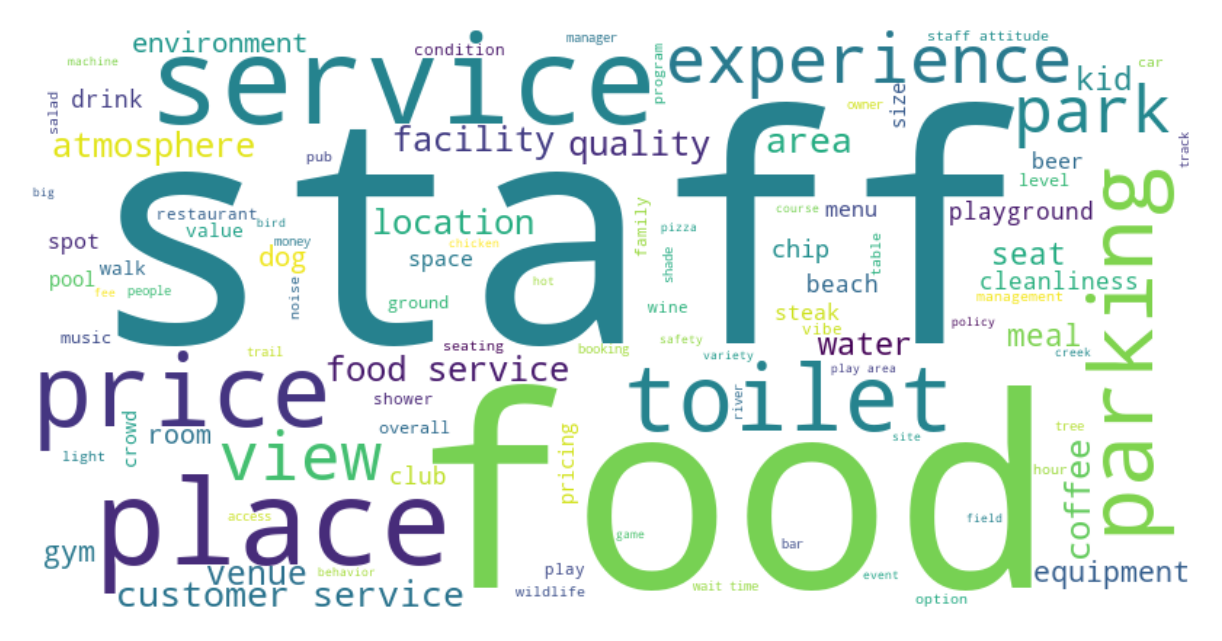

In [56]:
from wordcloud import WordCloud, STOPWORDS

# for i in np.unique(labels):
text = " ".join(df_cat['aspect'].values)

wordcloud1 = WordCloud(width=800, height=400, background_color='white', 
                    stopwords=set(STOPWORDS), max_words=100).generate(text)
print('*************************')
print(i)
plt.figure(figsize=(5, 5))
plt.imshow(wordcloud1, interpolation='bilinear')
plt.axis('off') 
plt.show()

In [1]:
category_defs = {
    "staff_attitude": {
        "label": "Staff attitude and professionalism",
        "description": (
            "How staff, employees, volunteers and managers behave, "
            "including politeness, respect, helpfulness, competence and professionalism."
        ),
        "examples": [
            "employee behavior",
            "staff attitude",
            "staff behaviour",
            "rude chef",
            "staff refusal",
            "staff inattentiveness",
            "staff friendliness",
            "staff helpfulness",
            "manager's customer service skills",
            "approach to handling customers",
            "professionalism",
        ],
    },

    "service_process": {
        "label": "Service process and operations",
        "description": (
            "Speed, reliability and organization of the service, including waiting times, "
            "queues, ordering, delivery, booking, billing and problem resolution."
        ),
        "examples": [
            "customer service",
            "service quality",
            "order accuracy",
            "wait time",
            "waiting time",
            "service delay",
            "delivery process",
            "delivery driver",
            "online booking process",
            "website/booking disclosure",
            "membership cancellation",
            "billing system",
            "ticketing system",
            "inquiry response",
        ],
    },

    "food_drink": {
        "label": "Food and drink quality",
        "description": (
            "Quality, taste, freshness, temperature, portion size and variety of food and drink, "
            "including specific dishes and menu items."
        ),
        "examples": [
            "food",
            "meal",
            "meal quality",
            "food quality",
            "steak quality",
            "steak preparation",
            "fish and chips",
            "burger",
            "pizza",
            "squid salad",
            "vegetarian burger",
            "dessert",
            "coffee",
            "beer",
            "cocktail glass",
            "wine",
        ],
    },

    "pricing_value": {
        "label": "Pricing and value for money",
        "description": (
            "Perceived fairness of prices and overall value for money, including fees, surcharges "
            "and discounts."
        ),
        "examples": [
            "price",
            "pricing",
            "pricing policy",
            "menu prices",
            "value for money",
            "overprice",
            "entry price",
            "admission fee",
            "parking fee",
            "surcharge",
            "transaction fee",
            "cheap tickets",
            "concession rate",
        ],
    },

    "location_access": {
        "label": "Location and access",
        "description": (
            "Geographic location, convenience of getting there and ease of access, "
            "including parking and paths."
        ),
        "examples": [
            "location",
            "near",
            "City",
            "accessibility",
            "customer access",
            "bridge",
            "road",
            "pathway",
            "walking trail",
        ],
    },

    "facilities_amenities": {
        "label": "Facilities and amenities",
        "description": (
            "Availability and suitability of physical facilities and amenities, including toilets, "
            "seating, play areas, sports facilities and built structures."
        ),
        "examples": [
            "toilet",
            "toilet block",
            "toilet facilities",
            "amenities block",
            "seat",
            "seating/tables and chairs",
            "playground",
            "kids play area",
            "skate park",
            "pool",
            "sea pool",
            "swimming area",
            "spa",
            "gym equipment",
            "cabin",
            "campground",
            "caravan park",
            "function room",
            "cinema",
            "stadium",
            "parking",
            "car park",
            "car parking",
            "parking availability",
            "car spaces",
        ],
    },

    "cleanliness_maintenance": {
        "label": "Cleanliness and maintenance",
        "description": (
            "Hygiene, cleanliness and physical upkeep of places, facilities and equipment, "
            "including litter and visible wear."
        ),
        "examples": [
            "cleanliness",
            "clean place",
            "clean amenities",
            "hygiene issue",
            "maintenance",
            "park maintenance",
            "facility condition",
            "ground conditions",
            "park condition",
            "rubbish bin",
            "rubbish",
            "trash presence",
            "litter",
            "damaged items",
            "spider web",
            "bird poo",
        ],
    },

    "atmosphere_vibe": {
        "label": "Atmosphere, vibe and comfort",
        "description": (
            "Overall vibe, mood and comfort of the place, including noise, music, crowding "
            "and general feel."
        ),
        "examples": [
            "vibe",
            "club vibe",
            "atmosphere",
            "ambience",
            "atmosphere/magic",
            "music",
            "noise",
            "noise level",
            "crowd",
            "crowd levels",
            "busy",
            "calm",
            "peace and quiet",
            "family friendly",
            "fun environment",
            "temperature",
            "hot inside",
            "air conditioning",
        ],
    },

    "natural_environment": {
        "label": "Natural environment, scenery and wildlife",
        "description": (
            "Natural setting, scenery and wildlife, including views, landscapes, water features "
            "and animals."
        ),
        "examples": [
            "view",
            "scenic view",
            "panoramic view",
            "surroundings",
            "natural scenery",
            "park",
            "beach",
            "river",
            "lake",
            "valley",
            "bushland",
            "waterfall",
            "wildlife",
            "Aussie birds",
            "Cockatoos",
            "snake",
            "koala",
            "nature reserve",
        ],
    },

    "activities_events": {
        "label": "Activities, events and programs",
        "description": (
            "Recreational activities, sports, events, classes and organized programs provided at the place."
        ),
        "examples": [
            "hike",
            "walking trails",
            "bushwalking tracks",
            "bike path",
            "driving range",
            "golf course",
            "street hockey",
            "skatepark",
            "kids party",
            "kids club",
            "swimming classes",
            "fitness class",
            "gym program",
            "event",
            "concert",
            "trivia",
            "bingo",
            "Sunset Cruise",
        ],
    },

    "safety_security": {
        "label": "Safety and security",
        "description": (
            "Perceived and actual safety and security, including rules, supervision and protective measures."
        ),
        "examples": [
            "security measures",
            "security",
            "lifeguard",
            "bouncer",
            "dog safety",
            "child safety",
            "rule",
            "fair play",
            "OHS measures",
            "duty of care",
            "supervision",
            "safety for ducks",
            "water levels",
            "bushfire",
        ],
    },

    "policies_governance": {
        "label": "Policies, administration and governance",
        "description": (
            "Policies, administrative decisions, rules and governance, including council or management actions."
        ),
        "examples": [
            "membership contract",
            "membership cancellation policy",
            "membership",
            "terms and conditions",
            "dress code",
            "dog policy",
            "council",
            "Parks Dept management",
            "management",
            "funding",
            "equity program",
        ],
    },

    "inclusivity_community": {
        "label": "Inclusivity, family friendliness and community",
        "description": (
            "Inclusiveness and community orientation of the place, including suitability for families, "
            "children, diverse groups and local community engagement."
        ),
        "examples": [
            "Dog Area",
            "LGBTQ+ space",
            "Pride flags and banners",
            "community",
            "unity centre",
            "multicultural environment",
        ],
    },

    "overall_experience": {
        "label": "Overall experience and summary evaluations",
        "description": (
            "Global evaluations of the visit or place that are not tied to a single specific feature."
        ),
        "examples": [
            "overall",
            "overall experience",
            "experience",
            "visit",
            "stay",
            "worth visiting",
            "must-see value",
            "recommendation",
            "negative experience",
        ],
    },

    "other": {
        "label": "Other or uncategorised",
        "description": (
            "Aspects that do not clearly fit any of the defined categories or are too vague "
            "to classify reliably."
        ),
        "examples": [
            "place",
            "spot",
            "thing",
            "general area",
            "everything else",
        ],
    },
}


In [3]:
category_defs.keys()

dict_keys(['staff_attitude', 'service_process', 'food_drink', 'pricing_value', 'location_access', 'facilities_amenities', 'cleanliness_maintenance', 'atmosphere_vibe', 'natural_environment', 'activities_events', 'safety_security', 'policies_governance', 'inclusivity_community', 'overall_experience', 'other'])

In [84]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("all-mpnet-base-v2")

def embed(texts):
    return model.encode(texts, normalize_embeddings=True)

# Category representations: combine label + description + examples
cat_texts = {
    key: cat["label"] + ". " + cat["description"] + ". " + "; ".join(cat["examples"])
    for key, cat in category_defs.items()
}

cat_vecs = {key: embed([txt])[0] for key, txt in cat_texts.items()}

In [85]:
def assign_category(aspect, cat_vecs, model, threshold=0.3):
    """
    aspect: string
    cat_vecs: dict from category key to embedding
    model: SentenceTransformer model
    threshold: if best similarity < threshold, label as 'other'
    """
    v = model.encode([aspect], normalize_embeddings=True)[0]
    best_key = None
    best_score = -1.0

    for key, cv in cat_vecs.items():
        score = float(np.dot(v, cv))  # cosine similarity because vectors are normalised
        if score > best_score:
            best_score = score
            best_key = key

    if best_score < threshold:
        return "other", best_score

    return best_key, best_score


In [86]:
records = []
for a in df_cat['aspect']:
    cat, score = assign_category(a, cat_vecs, model, threshold=0.1)
    records.append(
        {
            "aspect": a,
            "category_key": cat,
            "category_label": category_defs[cat]["label"],
            "similarity": score,
        }
    )

df = pd.DataFrame(records)


In [87]:
df.head()

,aspect,category_key,category_label,similarity
0,employee...,staff_at...,Staff at...,0.6085
1,location,location...,Location...,0.2888
2,tourist ...,overall_...,Overall ...,0.2938
3,crowd,atmosphe...,Atmosphe...,0.2766
4,spot,other,Other or...,0.1828


In [91]:
df[df['category_label'] == 'Activities, events and programs'].loc[:, ['aspect', 'similarity']]

,aspect,similarity
24,playground,0.3535
30,shows an...,0.2376
32,course c...,0.2220
53,dance,0.2644
60,hike,0.2652
...,...,...
2462,waterpark,0.3350
2463,ride opt...,0.2449
2468,instruction,0.2470
2492,game,0.1779


In [89]:
# Counts per category
counts = df["category_label"].value_counts().sort_values(ascending=False)
print(counts)

# Save the full table to Excel
# df.to_excel("aspect_categories_auto.xlsx", index=False)


category_label
Food and drink quality                            389
Activities, events and programs                   291
Service process and operations                    217
Atmosphere, vibe and comfort                      213
Staff attitude and professionalism                195
Inclusivity, family friendliness and community    184
Facilities and amenities                          164
Other or uncategorised                            158
Cleanliness and maintenance                       144
Location and access                               141
Overall experience and summary evaluations        124
Natural environment, scenery and wildlife         107
Pricing and value for money                       103
Policies, administration and governance            42
Safety and security                                37
Name: count, dtype: int64


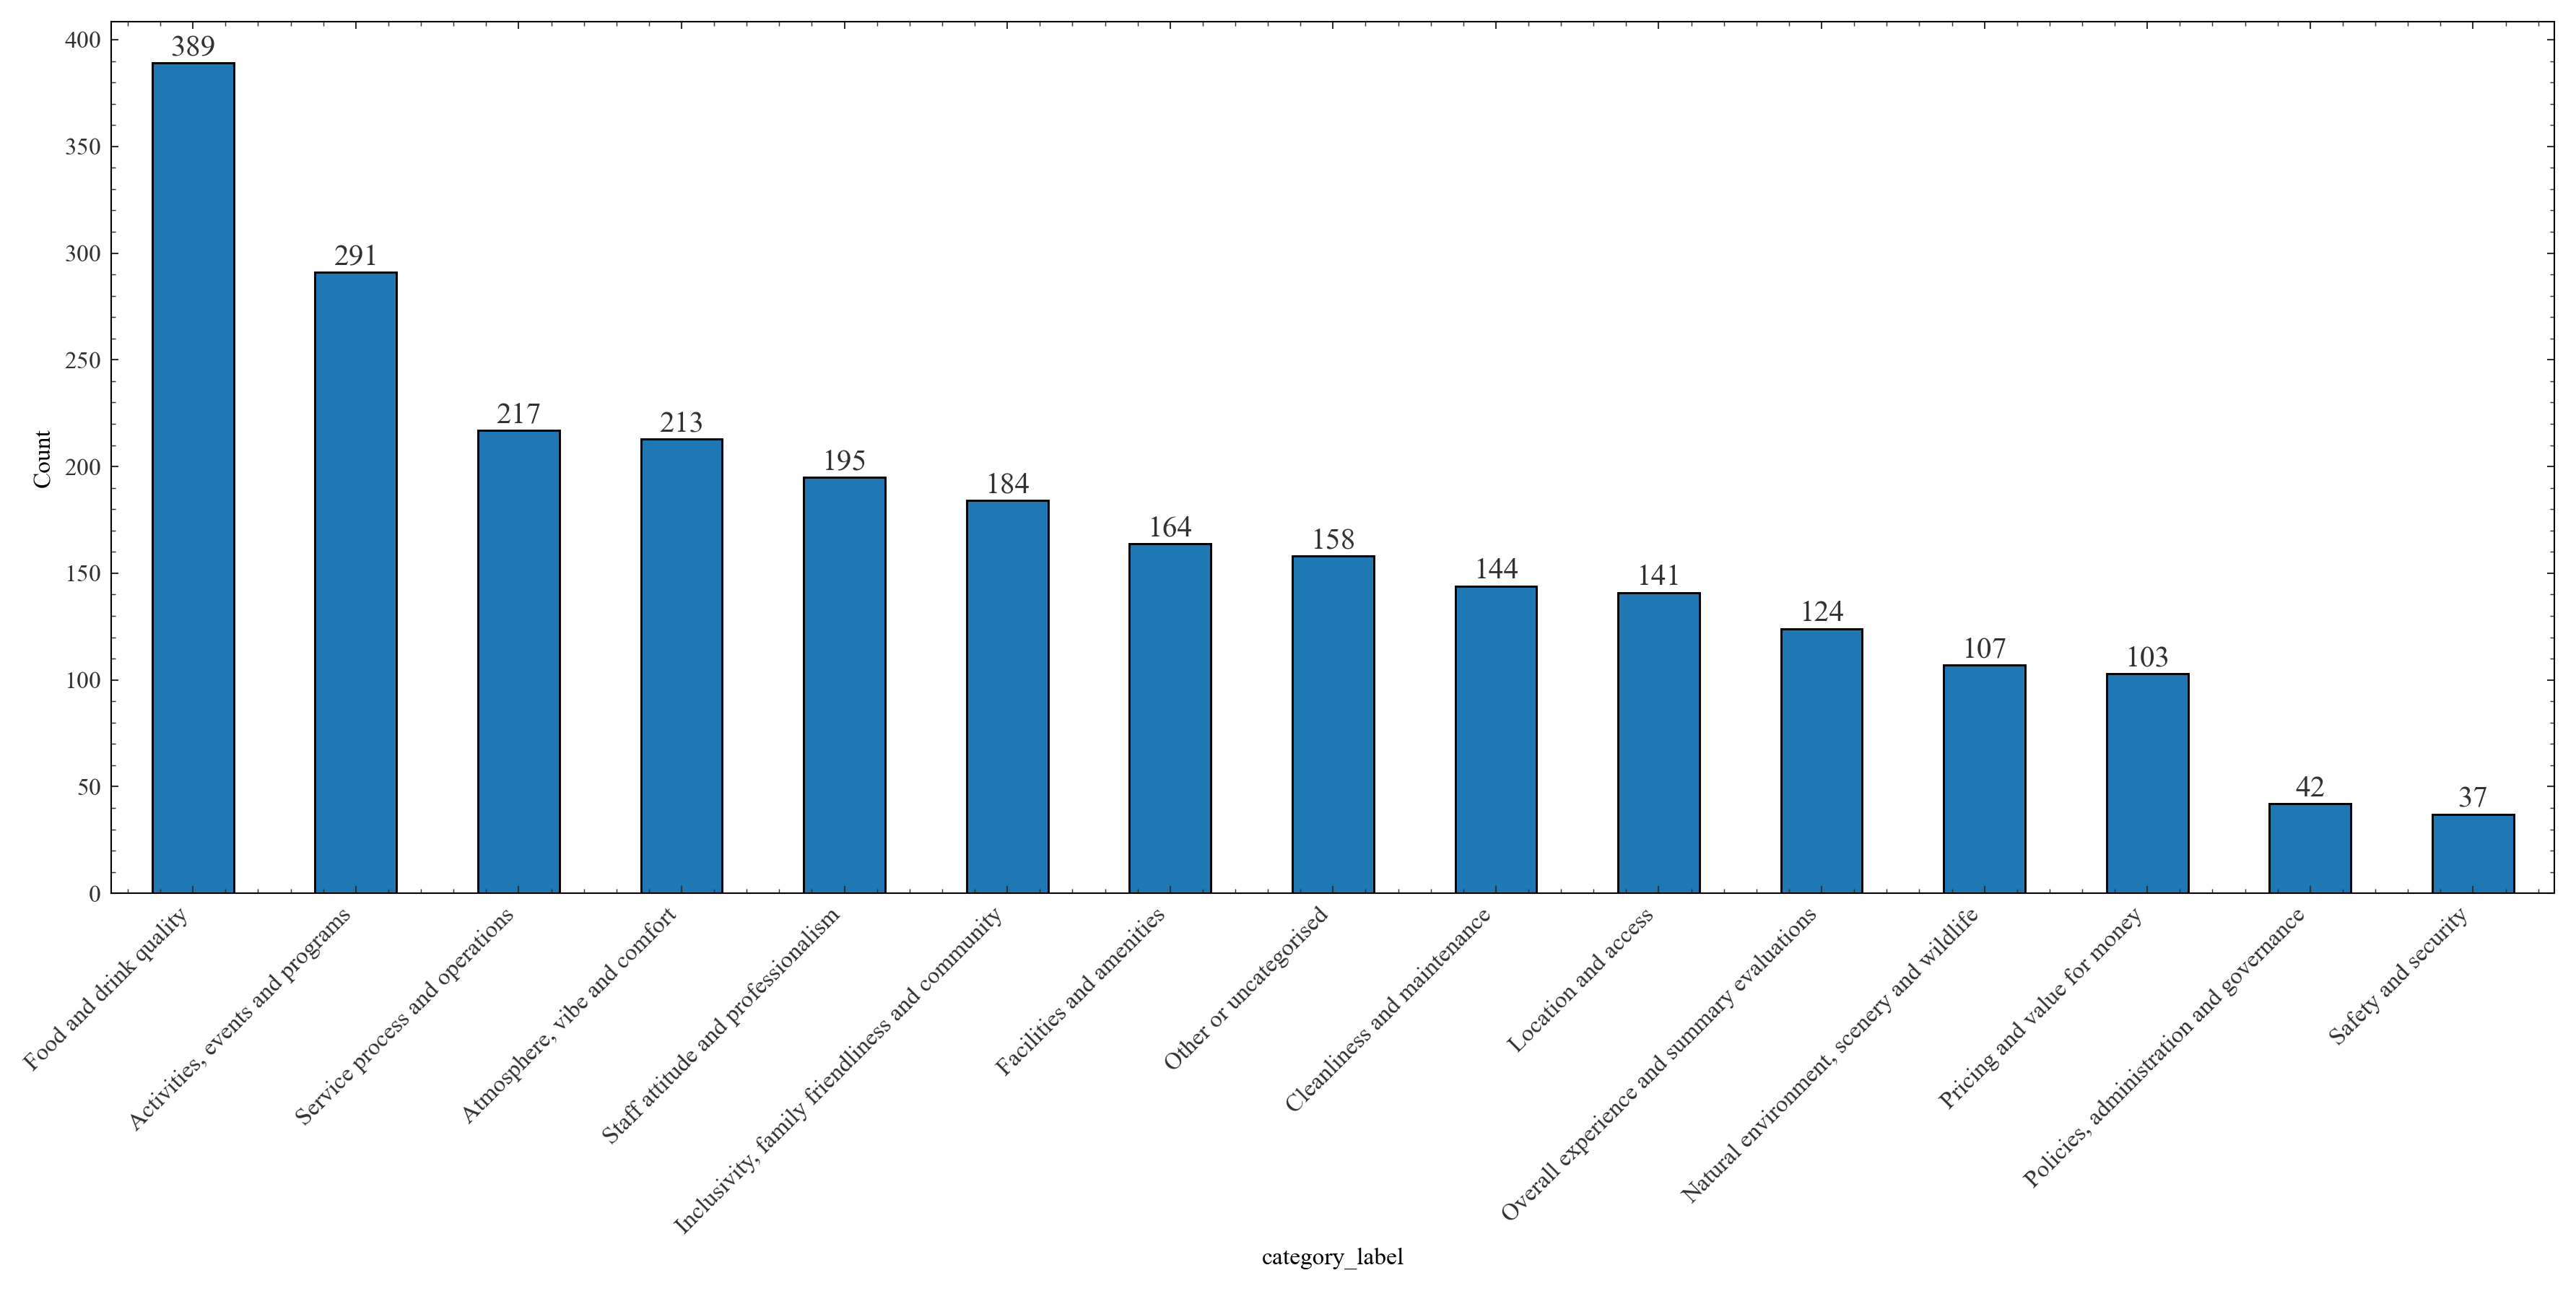

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
ax = counts.plot(kind="bar")

# Add data labels
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.5, str(v), ha='center', va='bottom', fontsize=10)

plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
